# Gaussianize-then-cluster
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/rbig/blob/main/docs/notebooks/22_gaussianize_then_cluster.ipynb)

K-means assumes round, equal-variance clusters and cuts along the wrong
axis on **elongated** data. `RBIGKMeans` clusters in the Gaussianized
latent space — where the geometry is calibrated — and maps the
centroids back to data space for interpretation.

> **Colab / fresh environment?** Run the cell below to install `rbig`.
> Skip if already installed.

In [ ]:
!pip install "rbig[all] @ git+https://github.com/jejjohnson/rbig.git" -q

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

from rbig import RBIGKMeans

plt.style.use("seaborn-v0_8-paper")

/home/user/rbig/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data: two parallel elongated clusters

Raw k-means splits them across the long axis; the true split is
top/bottom.

In [3]:
rng = np.random.default_rng(1)
per = 250
X = np.vstack(
    [
        rng.standard_normal((per, 2)) * [3.0, 0.3] + [0, +2.0],
        rng.standard_normal((per, 2)) * [3.0, 0.3] + [0, -2.0],
    ]
)
y_true = np.repeat([0, 1], per)

raw = KMeans(n_clusters=2, n_init=5, random_state=0).fit_predict(X)
rbig = RBIGKMeans(n_clusters=2, n_layers_rbig=3, n_init=5, random_state=0).fit(X)

ari_raw = adjusted_rand_score(y_true, raw)
ari_rbig = adjusted_rand_score(y_true, rbig.labels_)

## Before vs after

Left: raw k-means on X. Right: `RBIGKMeans`, with the data-space
centroids marked.

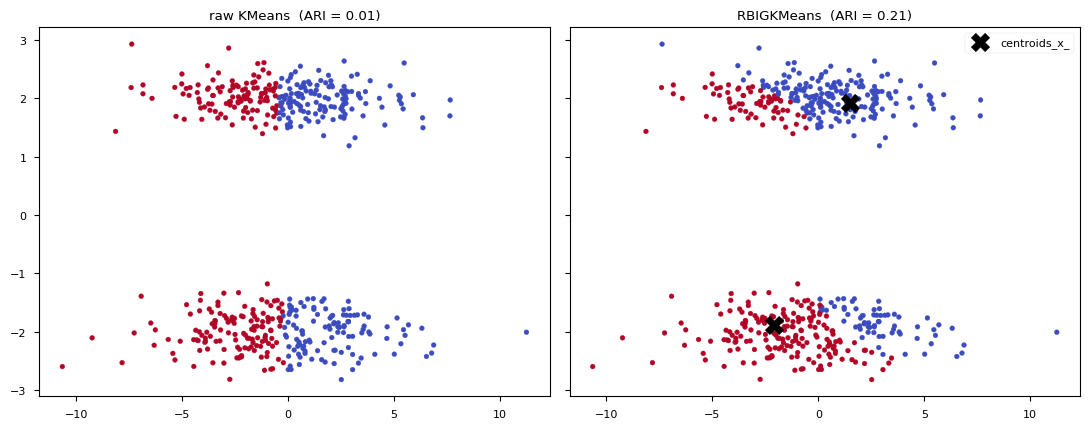

In [4]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True, sharey=True)
ax0.scatter(X[:, 0], X[:, 1], c=raw, cmap="coolwarm", s=12)
ax0.set_title(f"raw KMeans  (ARI = {ari_raw:.2f})")
ax1.scatter(X[:, 0], X[:, 1], c=rbig.labels_, cmap="coolwarm", s=12)
ax1.scatter(
    rbig.centroids_x_[:, 0],
    rbig.centroids_x_[:, 1],
    marker="X",
    s=180,
    c="black",
    label="centroids_x_",
)
ax1.set_title(f"RBIGKMeans  (ARI = {ari_rbig:.2f})")
ax1.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

In [5]:
print(f"raw KMeans ARI:  {ari_raw:.3f}")
print(f"RBIGKMeans ARI:  {ari_rbig:.3f}")

raw KMeans ARI:  0.005
RBIGKMeans ARI:  0.206


## Takeaways

- Clustering in the calibrated latent space recovers the true split
  where raw k-means cannot. See the elongated-cluster row of the
  [benchmarks](../benchmarks.md) for the multi-seed ARI gap.
- **`n_layers_rbig` defaults small (10) on purpose.** Multi-modality
  *is* non-Gaussianity, so a deep flow Gaussianizes away the very
  between-cluster structure you want to cluster on. On well-separated
  axis-aligned modes, raw k-means actually wins — a documented,
  regression-tested trade-off.
- Choose `n_clusters` with a silhouette score computed on
  `transform(X)` (the Z-space), not on raw X.